# Recurrent Neural Networks (RNN)

Traditional neural networks process each input independently and cannot remember previous information. However, language is sequential, and the meaning of a sentence depends on the words that came before.

Recurrent Neural Networks (RNNs) solve this problem by introducing a hidden state that carries information from previous time steps. As each word in a sentence is processed, the hidden state is updated, allowing the network to remember earlier context.

This ability makes RNNs suitable for tasks such as sentiment analysis, language modeling, machine translation, and text classification. Although modern architectures like Transformers have largely replaced RNNs in many applications, understanding RNNs provides the foundation for learning LSTMs and GRUs.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sentences = [

    "I love machine learning",

    "Deep learning is powerful",

    "Artificial intelligence is amazing",

    "Natural language processing is interesting"

]

In [3]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(

    sequences,

    padding="post"

)

print(padded_sequences)

[[ 3  4  5  2  0]
 [ 6  2  1  7  0]
 [ 8  9  1 10  0]
 [11 12 13  1 14]]


In [4]:
model = Sequential([

    Embedding(

        input_dim=100,

        output_dim=16,

        input_length=padded_sequences.shape[1]

    ),

    SimpleRNN(32),

    Dense(1, activation="sigmoid")

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [7]:
labels = np.array([1, 1, 0, 0])

In [8]:
history = model.fit(

    padded_sequences,

    labels,

    epochs=10,

    verbose=1

)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 0.6945
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7500 - loss: 0.6828
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7500 - loss: 0.6712
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7500 - loss: 0.6595
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7500 - loss: 0.6476
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.6354
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6228
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.6099
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.5965
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.5826


In [9]:
predictions = model.predict(padded_sequences)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
[[0.57229614]
 [0.5569434 ]
 [0.466317  ]
 [0.3944045 ]]


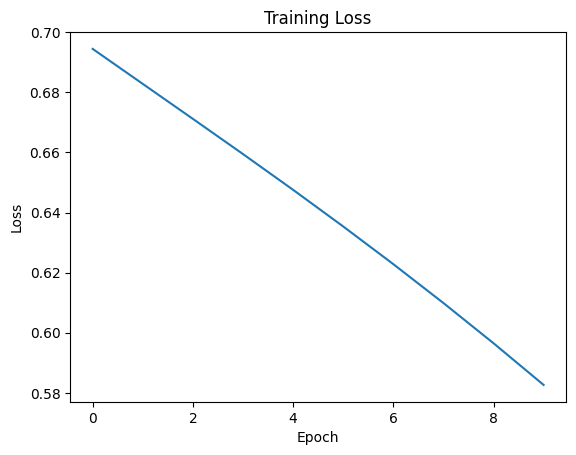

In [10]:
plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [11]:
import pandas as pd

comparison = pd.DataFrame({

    "Feedforward Network":[

        "Processes each input independently",

        "No memory",

        "Ignores sequence"

    ],

    "RNN":[

        "Processes one step at a time",

        "Maintains hidden state",

        "Preserves sequence"

    ]

})

comparison

,Feedforward Network,RNN
0,Processes each input independently,Processes one step at a time
1,No memory,Maintains hidden state
2,Ignores sequence,Preserves sequence


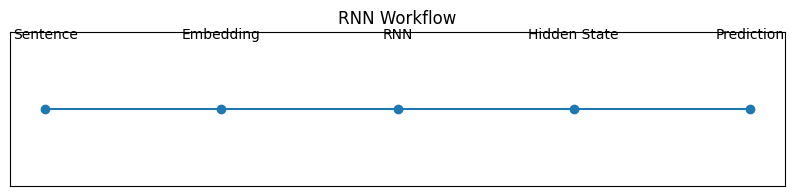

In [12]:
steps = [

    "Sentence",

    "Embedding",

    "RNN",

    "Hidden State",

    "Prediction"

]

plt.figure(figsize=(10,2))

plt.plot(

    range(len(steps)),

    [1]*len(steps),

    marker="o"

)

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("RNN Workflow")

plt.show()